# **Первые 2 пункта из кейса по молоку**

## Импорт необходимых библиотек:

In [ ]:
from zipfile import ZipFile
from pathlib import Path
from scipy.interpolate import make_interp_spline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

## Решение

In [ ]:
# Путь к архиву и к папке распаковки
archive = '/content/csv_ivium_new_data.zip'

# Извлечение из архива в папку
with ZipFile(archive, 'r') as zipka:
    zipka.extractall(papka)

# Преобразование строкового пути папки в объект
data_dir = Path(papka)

# Поиск и подсчет всех csv-файлов (кроме скрытых macOS (._))
csv_files = [f for f in data_dir.glob("**/*.csv") if not f.name.startswith('._')]
print("Найдено CSV-файлов (без системных):", len(csv_files))

# Инициализация переменных
voltages = None # для считывания развертки потенциалов
df_data = [] # список для данных
graph_data = {}  # словарь для хранения данных для графиков

for csv_file in csv_files:
    try:
        df = pd.read_csv(csv_file, index_col=0) # временный df для чтения одного файла
        df.columns = df.columns.str.replace(r'[,\s]+', '_', regex=True) # ликвидация пробелов в названиях

        # Считывание развертки потенциалов (Voltage_V) один раз
        if 'Voltage_V' in df.columns and 'Current_A' in df.columns:
            if voltages is None:
                voltages = np.array(df['Voltage_V'].values)
                voltages = np.round(voltages, 3)  # округление до 3 знаков после запятой

            # Считывание силы тока
            currents = np.array(df['Current_A'].values)

            # Работа с названием файла
            parts = csv_file.stem.split('_')
            if len(parts) >= 2:
                antibiotic = parts[0]
                concentration = parts[1]
            else:
                antibiotic = None
                concentration = None

            # Добавление в список словаря со значениями
            data_dict = {f"{v:.3f}": f"{c:.5e}" for v, c in zip(voltages, currents)}
            data_dict['antibiotic'] = antibiotic
            data_dict['concentration'] = concentration
            df_data.append(data_dict)

            # Подготовка данных для вольтамперограммы:
            if antibiotic in graph_data:
                graph_data[antibiotic]['currents'].append(currents)
            else:
                graph_data[antibiotic] = {
                    'voltages': np.sort(voltages),
                    'currents': [currents]
                }

        else: print(f"Файл {csv_file.name} не содержит столбцов Voltage_V / Current_A")

    except Exception as e: print(f"Ошибка при чтении файла {csv_file.name}: {e}")

# Создание единого DataFrame и форматирование значений в e-нотацию (как в примере)
df_final = pd.DataFrame(df_data)
pd.options.display.float_format = '{:.5e}'.format

# Определение диапазона концентраций
df_final['concentration'] = pd.to_numeric(df_final['concentration'], errors='coerce')
range_df = (df_final.groupby('antibiotic')['concentration'].agg(['min', 'max']).reset_index())

# Уникальные антибиотики + количество измерений
unique_ants = df_final['antibiotic'].dropna().unique()
counts = df_final['antibiotic'].value_counts()

Найдено CSV-файлов (без системных): 1377


## Консольный вывод и графики:

---------------------------------------------------------------
Пример данных из итогового DataFrame:

         -0.800        -0.795        -0.790        -0.785        -0.780  \
0  -2.95634e-05  -2.92955e-05  -2.91931e-05  -2.90935e-05  -2.89770e-05   
1  -2.90469e-05  -3.26083e-05  -3.24081e-05  -3.22226e-05  -3.20285e-05   
2  -2.90652e-05  -3.84466e-05  -3.85079e-05  -3.85845e-05  -3.86612e-05   
3  -4.45076e-05  -3.01842e-05  -3.00769e-05  -2.99696e-05  -2.98470e-05   
4  -2.40985e-05  -2.52482e-05  -2.51869e-05  -2.51256e-05  -2.50489e-05   

         -0.775        -0.770        -0.765        -0.760        -0.755  ...  \
0  -2.88869e-05  -2.87822e-05  -2.86780e-05  -2.85876e-05  -2.84975e-05  ...   
1  -3.18323e-05  -3.16387e-05  -3.14409e-05  -3.12473e-05  -3.10403e-05  ...   
2  -3.87532e-05  -3.88605e-05  -3.89678e-05  -3.90751e-05  -3.92130e-05  ...   
3  -2.97397e-05  -2.96170e-05  -2.95097e-05  -2.94024e-05  -2.92951e-05  ...   
4  -2.50030e-05  -2.49570e-05  -2.49263e-05  -

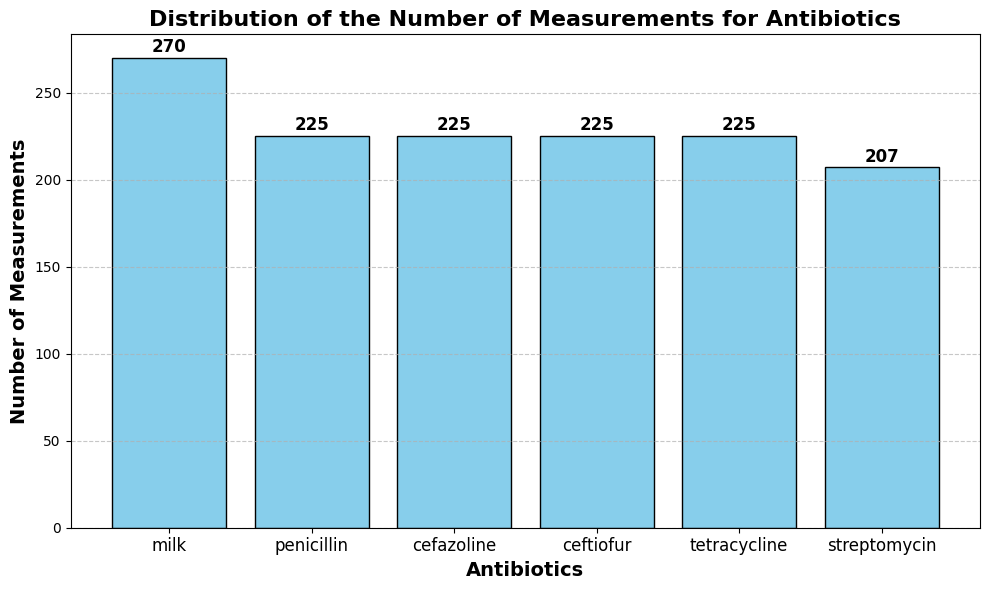

Вольтамперограмма для penicillin сохранена как penicillin_VA.png
Вольтамперограмма для streptomycin сохранена как streptomycin_VA.png
Вольтамперограмма для ceftiofur сохранена как ceftiofur_VA.png
Вольтамперограмма для cefazoline сохранена как cefazoline_VA.png
Вольтамперограмма для tetracycline сохранена как tetracycline_VA.png
Вольтамперограмма для milk сохранена как milk_VA.png


In [ ]:
# Пример данных из таблицы
print('---------------------------------------------------------------')
print("Пример данных из итогового DataFrame:")
print()
print(df_final.head())

# Сохранение в CSV
df_final.to_csv('final_data.csv', index=True, float_format='%.5e')
print("Итоговая таблица сохранена в файле: final_data.csv")

# Консольный вывод диапазона концентраций
print('---------------------------------------------------------------')
print('Диапазон концентраций для каждого антибиотика:')
print(range_df)

# Консольный вывод уникальных антибиотиков
print('---------------------------------------------------------------')
print(f"Число уникальных антибиотиков: {len(unique_ants)}")
print("Список антибиотиков:", unique_ants)

# Столбчатая диаграмма
plt.figure(figsize=(10, 6))
bars = plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 1, int(yval),
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.xlabel('Antibiotics', fontsize=14, fontweight='bold')
plt.ylabel('Number of Measurements', fontsize=14, fontweight='bold')
plt.title('Distribution of the Number of Measurements for Antibiotics',
          fontsize=16, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.savefig('improved_hist_antibiotics.png', dpi=300)
plt.show()

# Вольтамперограмма
output_dir = Path("VA_graphs") # Папка для сохранения графиков
output_dir.mkdir(exist_ok=True)

# Построение графиков для каждого антибиотика
for antibiotic, data in graph_data.items():
    voltages_sorted = data['voltages']
    currents_sorted = random.choice(data['currents']) # случайное измерение силы тока из данных этого антибиотика

    # Построение вольтамперограммы:
    plt.figure(figsize=(8, 6))
    plt.plot(voltages_sorted, currents_sorted, color='blue', linestyle='-')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlabel("Voltage (V)", fontsize=14, fontweight='bold')
    plt.ylabel("Current (A)", fontsize=14, fontweight='bold')
    plt.title(f"Вольтамперограмма для {antibiotic}", fontsize=16, fontweight='bold')

    # Название файла с именем антибиотика:
    filename = f"{antibiotic}_VA.png"
    plt.savefig(output_dir / filename, dpi=300)
    plt.close()
    print(f"Вольтамперограмма для {antibiotic} сохранена как {filename}")

# **Последние 2 пункта из кейса по молоку**


![ГипноДэнс](https://media1.tenor.com/m/Auk7dhgC6xMAAAAd/meme-polish-cow.gif)

## Импорт необходимых библиотек:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

## Загрузка данных (с Гугл диска)

In [2]:
file_id = '1Kie6Fd5xmQHOVjZPliLGa3hz0EzITrEz'
url = f'https://drive.google.com/uc?id={file_id}'
df = pd.read_csv(url, header=0, index_col=0)

❗Нужно запустить *ОДНУ ИЗ ДВУХ*  ячеек ниже

## Подготовка данных для **Бинарной классификации**

In [3]:
df_binary = df.copy()
df_binary['target'] = (df_binary['antibiotic'] != 'milk').astype(int)
df_binary = df_binary.drop(columns=['antibiotic'])

X = df_binary.select_dtypes(include=['number']).drop(columns=['target'])
y = df_binary['target']

## Подготовка данных для **Многоклассовой классификации**

In [4]:
df_multi = df.copy()
X = df_multi.drop(columns=['antibiotic']).select_dtypes(include=['number'])
y = df_multi['antibiotic']

## Масштабирование

In [4]:
def scale_data(X_train, X_test):

    """
    Масштабирует данные двумя способами:
    - Стандартизация (StandardScaler) для k-NN и ЛогРег
    - Нормализация (MinMaxScaler) для остальных моделей
    """
    scaler_std = StandardScaler()
    scaler_minmax = MinMaxScaler()

    X_train_std = scaler_std.fit_transform(X_train)
    X_test_std = scaler_std.transform(X_test)

    X_train_norm = scaler_minmax.fit_transform(X_train)
    X_test_norm = scaler_minmax.transform(X_test)

    return X_train_std, X_test_std, X_train_norm, X_test_norm


def prepare_scaled_data(X_train, X_test):

    """
    Использует функцию scale_data() для масштабирования признаков,
    затем формирует словари:
    - X_train_dict и X_test_dict, где каждому классификатору сопоставляется
      нужный тип масштабированных признаков.
    """
    X_train_std, X_test_std, X_train_norm, X_test_norm = scale_data(X_train, X_test)

    X_train_dict = {
        'Logistic Regression': X_train_std,
        'k-NN': X_train_std,
        'Random Forest': X_train_norm,
        'SVM': X_train_norm,
        'Gradient Boosting': X_train_norm
    }

    X_test_dict = {
        'Logistic Regression': X_test_std,
        'k-NN': X_test_std,
        'Random Forest': X_test_norm,
        'SVM': X_test_norm,
        'Gradient Boosting': X_test_norm
    }

    return X_train_dict, X_test_dict

## Обучение моделей

In [5]:
def tune_model(model, param_grid, X_train, y_train, average='macro', cv=5):

    """
    Подбор параметров модели с помощью GridSearchCV
    """
    grid = GridSearchCV(
      model,
      param_grid,
      scoring='f1' if average == 'binary' else f'f1_{average}',
      cv=cv,
      n_jobs=-1
)
    grid.fit(X_train, y_train)

    print(f"✅ {type(model).__name__}: лучшие параметры — {grid.best_params_}, f1 = {grid.best_score_:.4f}")
    return grid.best_params_

def get_models(best_logreg, best_knn, best_rf, best_gb):
    return {
        'Logistic Regression': LogisticRegression(**best_logreg, max_iter=1000, random_state=42),
        'k-NN': KNeighborsClassifier(**best_knn),
        'Random Forest': RandomForestClassifier(**best_rf, random_state=42),
        'SVM': SVC(probability=True, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(**best_gb, random_state=42)
    }


def train_and_evaluate(models, X_train_dict, X_test_dict, y_train, y_test, average=None):

    # Автоматический выбор режима
    if average is None:
        n_classes = len(np.unique(y_train))
        average = 'binary' if n_classes == 2 else 'macro'

    results = {}
    for name, model in models.items():
        X_train_scaled = X_train_dict[name]
        X_test_scaled = X_test_dict[name]

        print(f"🔧 Обучение модели: {name}")
        start = time.time()

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        end = time.time()
        print(f"⏱️ {name}: {end - start:.2f} сек\n")

        acc = accuracy_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred, average=average)
        f1 = f1_score(y_test, y_pred, average=average)

        results[name] = {
            'accuracy': acc,
            'recall': rec,
            'f1_score': f1
        }
    return results


def get_best_model_name(results):
    return max(results, key=lambda name: results[name]['f1_score'])


def show_results_table(results):
    results_df = pd.DataFrame(results).T.round(4)
    display(results_df)

## Матрица ошибок

In [6]:
def show_confusion_matrix(model, X_test_scaled, y_test):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title(f"Матрица ошибок: {type(model).__name__}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

## ROC-кривые + AUC

In [7]:
def plot_roc_auc(models, X_test_dict, y_test):

    # Проверим, бинарная ли задача
    if len(np.unique(y_test)) != 2:
        print("ROC и AUC доступны только для бинарной классификации. Пропускаем.")
        return

    roc_data = {}

    plt.figure(figsize=(8, 6))
    for name, model in models.items():
        X_test_scaled = X_test_dict[name]

        try:
            y_proba = model.predict_proba(X_test_scaled)[:, 1]
        except AttributeError:
            y_scores = model.decision_function(X_test_scaled)
            y_proba = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min())

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}

        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривые для всех моделей')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Main


✅ KNeighborsClassifier: лучшие параметры — {'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}, f1 = 0.9806
🔧 Обучение модели: Logistic Regression
⏱️ Logistic Regression: 0.20 сек

🔧 Обучение модели: k-NN
⏱️ k-NN: 0.34 сек

🔧 Обучение модели: Random Forest
⏱️ Random Forest: 1.45 сек

🔧 Обучение модели: SVM
⏱️ SVM: 0.98 сек

🔧 Обучение модели: Gradient Boosting
⏱️ Gradient Boosting: 9.46 сек



,accuracy,recall,f1_score
Logistic Regression,0.9239,0.9865,0.9542
k-NN,0.9384,0.9685,0.9620
Random Forest,0.9746,0.9955,0.9844
SVM,0.9130,0.9865,0.9481
Gradient Boosting,1.0000,1.0000,1.0000



🔥 Лучшая модель: Gradient Boosting



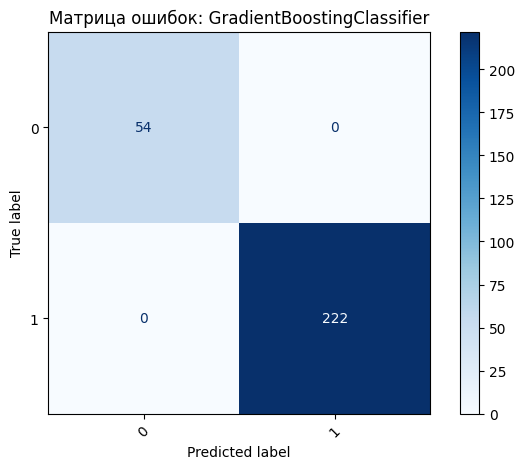

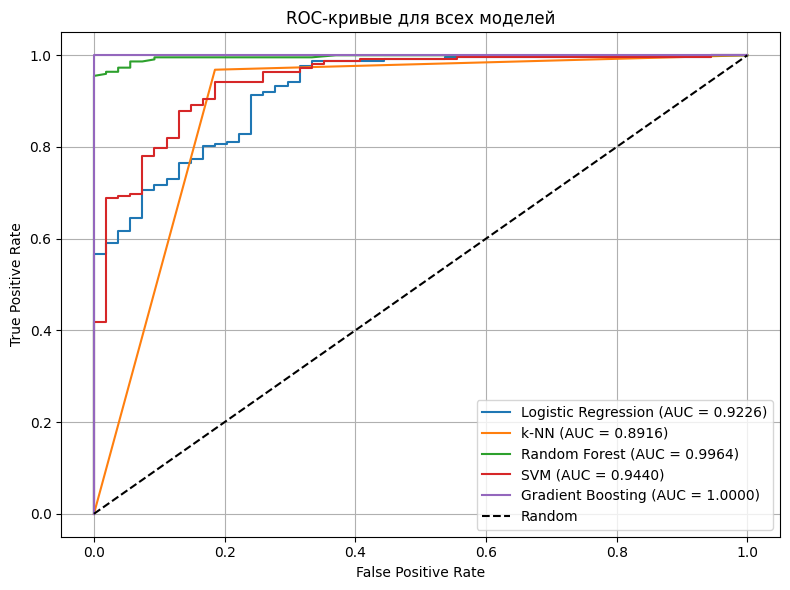


✅ Полное время выполнения мэйника: 50.05 сек


In [8]:
start = time.time()

# 1. Деление на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2. Масштабирование
X_train_dict, X_test_dict = prepare_scaled_data(X_train, X_test)

# 3. Определение типа задачи
average = 'binary' if len(np.unique(y_train)) == 2 else 'macro'

# 4. Только для k-NN — сетка параметров
param_knn = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# 5. Подбор параметров только для k-NN
best_knn = tune_model(KNeighborsClassifier(), param_knn, X_train_dict['k-NN'], y_train, average)

# 6. Остальные модели — дефолтные параметры
best_logreg = {}
best_rf = {}
best_gb = {}

# 7. Создание моделей
models = get_models(best_logreg, best_knn, best_rf, best_gb)

# 8. Обучение и вывод результатов
results = train_and_evaluate(models, X_train_dict, X_test_dict, y_train, y_test, average)
show_results_table(results)

# 9. Лучшая модель и матрица ошибок
best_model_name = get_best_model_name(results)
print()
print(f"🔥 Лучшая модель: {best_model_name}")
print()

show_confusion_matrix(models[best_model_name], X_test_dict[best_model_name], y_test)

# 10. ROC-кривая (если задача бинарная)
if average == 'binary':
    plot_roc_auc(models, X_test_dict, y_test)
else:
    print("ℹ️ Много классов → ROC-кривые не строятся.")

end = time.time()
print(f"\n✅ Полное время выполнения мэйника: {end - start:.2f} сек")